# Clustering Lab

 
Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data files will be in the canvas assignment, merging them together.

Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


In [24]:
# importing packages for lab
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Loading Data 
salary_data = pd.read_csv('2025_salaries.csv', header=1, encoding='latin-1')
# Header=1 because we want to let python know where the column starts
stats = pd.read_csv('nba_2025.txt', sep="," , encoding='latin-1')
# We want to seperate the data by commas

# Merging Data
merged_data = pd.merge(salary_data, stats, on='Player')

In [25]:
#Drop variables that will not be needed or are duplicates
# Got many duplicates after dropping them and searched up why, some players were on multiple teams, so I kept the 2TM row for those players and dropped the rest of the duplicates
# Keep the 2TM row for players on multiple teams
multi_team = merged_data[merged_data.duplicated(subset='Player', keep=False)]
multi_team = multi_team[multi_team['Tm'] == '2TM']

# Keep players who were only on one team (no duplicates)
single_team = merged_data[~merged_data.duplicated(subset='Player', keep=False)]

# Combine both
players = pd.concat([single_team, multi_team])
players = players.drop(['GS', 'Rk', 'Team', 'Awards', 'Player-additional', 'Trp-Dbl', 'FG', 'FGA', '3P', '3PA', '2P', '2PA', 'FT', 'FTA', 'ORB', 'DRB', '2P%', '3P%'], axis=1)
# Taking care of the unnecessary characters in the salary column and converting it to a float
players['2025-26'] = (players['2025-26'].str.replace(',', '')).str.replace('$', '').str.strip().astype(float)
# Taking care of missing values
players.dropna(inplace=True)
print(players)

                      Player   Tm     2025-26   Age Pos     G      MP    FG%  \
5               Monte Morris  IND    321184.0  30.0  PG   6.0    65.0  0.350   
6               E.J. Liddell  PHO    706898.0  25.0  PF  10.0    49.0  0.471   
7              James Wiseman  IND   1000000.0  24.0   C   4.0    58.0  0.600   
8    Olivier-Maxence Prosper  DAL   1002360.0  23.0  PF  29.0   398.0  0.492   
9                  Kam Jones  IND   1272870.0  23.0  SG  18.0   214.0  0.414   
..                       ...  ...         ...   ...  ..   ...     ...    ...   
507    Giannis Antetokounmpo  MIL  54126450.0  31.0  PF  30.0   876.0  0.645   
508            Anthony Davis  WAS  54126450.0  32.0  PF  20.0   626.0  0.506   
509             Kevin Durant  HOU  54708609.0  37.0  SF  50.0  1835.0  0.506   
510              Joel Embiid  PHI  55224526.0  31.0   C  31.0   972.0  0.494   
513            Stephen Curry  GSW  59606817.0  37.0  PG  39.0  1222.0  0.468   

      eFG%    FT%    TRB    AST   STL  

In [26]:
# Creating a new column for rebounds per game, points per game, points per minute, that will be used for the clustering
players['PPG'] = players['PTS'] / players['G']
players['PPM'] = players['PTS'] / players['MP']
players['RPG'] = players['TRB'] / players['G']
print(players.head())
players.info()

                    Player   Tm    2025-26   Age Pos     G     MP    FG%  \
5             Monte Morris  IND   321184.0  30.0  PG   6.0   65.0  0.350   
6             E.J. Liddell  PHO   706898.0  25.0  PF  10.0   49.0  0.471   
7            James Wiseman  IND  1000000.0  24.0   C   4.0   58.0  0.600   
8  Olivier-Maxence Prosper  DAL  1002360.0  23.0  PF  29.0  398.0  0.492   
9                Kam Jones  IND  1272870.0  23.0  SG  18.0  214.0  0.414   

    eFG%    FT%   TRB   AST  STL  BLK   TOV    PF    PTS       PPG       PPM  \
5  0.400  0.500   7.0   9.0  1.0  1.0   2.0   3.0   18.0  3.000000  0.276923   
6  0.588  0.667  11.0   0.0  1.0  0.0   0.0   4.0   22.0  2.200000  0.448980   
7  0.600  0.500   8.0   3.0  0.0  1.0   5.0  10.0   13.0  3.250000  0.224138   
8  0.585  0.870  83.0  19.0  8.0  4.0  20.0  26.0  185.0  6.379310  0.464824   
9  0.457  0.500  19.0  27.0  4.0  0.0   8.0  11.0   55.0  3.055556  0.257009   

        RPG  
5  1.166667  
6  1.100000  
7  2.000000  
8  2.8

In [27]:
scaler = StandardScaler()
# Scaling the features for clustering
features = ['G', 'MP', 'TRB', 'PTS', 'PPG', 'PPM', 'RPG', 'Age', 'FG%', 'eFG%', 'FT%', 'AST', 'STL', 'BLK', 'TOV', 'PF']
# Filter to players with at least 20 games to exclude players with very limited play time
players_filtered = players[players['G'] >= 20]
# Fit and transform the features
players_scaled = scaler.fit_transform(players_filtered[features])

In [28]:
#Run the clustering algo with your best guess for K

# Number of clusters to form as well as the number of centroids to generate
kmeans = KMeans(n_clusters=3, random_state=42, verbose=1)
kmeans.fit(players_scaled)

Initialization complete
Iteration 0, inertia 4168.838765558267.
Iteration 1, inertia 3105.077818188724.
Iteration 2, inertia 3041.4228923938235.
Iteration 3, inertia 3010.937896988517.
Iteration 4, inertia 2980.008368483846.
Iteration 5, inertia 2964.436918544291.
Iteration 6, inertia 2951.875489540523.
Iteration 7, inertia 2947.267867188936.
Iteration 8, inertia 2941.5754973727658.
Iteration 9, inertia 2939.1642616178497.
Iteration 10, inertia 2938.5468463387483.
Iteration 11, inertia 2938.130384522992.
Iteration 12, inertia 2936.547718654898.
Iteration 13, inertia 2935.7170047876607.
Iteration 14, inertia 2935.4661938717677.
Converged at iteration 14: strict convergence.


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",1
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [29]:
#View the results
# Assign cluster labels back to the dataframe
players_filtered['Cluster'] = kmeans.labels_
# Print cluster centers to see the centroid positions and labels to see which cluster each player was assigned to
print(kmeans.cluster_centers_)
print(kmeans.labels_)

[[ 0.61819252  1.03803341  0.93392662  1.13856823  1.02498797  0.86065838
   0.79589172  0.06939051  0.25059337  0.17110749  0.20768564  0.93497183
   0.77174533  0.56802118  1.10211021  0.8576526 ]
 [ 0.13870524 -0.0553577  -0.10751973 -0.27474748 -0.24401341 -0.30448089
  -0.06383405  0.08821345  0.12631312  0.21087291 -0.12167402 -0.23717137
   0.03785245 -0.01861112 -0.2979781   0.02422653]
 [-1.0566848  -1.28015833 -1.05283001 -1.03723755 -0.93946756 -0.61812568
  -0.94486832 -0.24314296 -0.54849163 -0.58815829 -0.06653201 -0.83195462
  -1.0872019  -0.72053887 -0.94911859 -1.17764243]]
[2 2 2 1 2 2 1 2 2 1 1 2 1 2 2 1 2 2 1 1 2 2 2 2 1 2 1 2 1 2 1 2 1 2 2 2 1
 2 2 0 1 2 2 2 1 1 1 1 2 2 1 1 2 0 2 0 2 2 2 1 1 1 0 1 1 1 2 1 1 2 1 1 1 1
 0 1 2 2 1 2 2 1 1 2 2 2 0 2 1 1 0 2 1 1 2 1 2 1 1 0 2 2 2 1 1 0 1 1 0 1 0
 2 2 2 0 1 0 2 0 0 2 2 2 2 1 1 1 0 1 1 0 2 1 1 1 2 0 1 1 1 2 0 1 1 0 1 0 1
 1 1 1 2 1 0 0 1 0 0 1 0 1 2 2 1 1 1 1 0 1 1 1 1 1 0 1 0 1 2 0 1 0 2 2 0 1
 1 0 1 0 2 0 2 1 1 1 0 1 1 

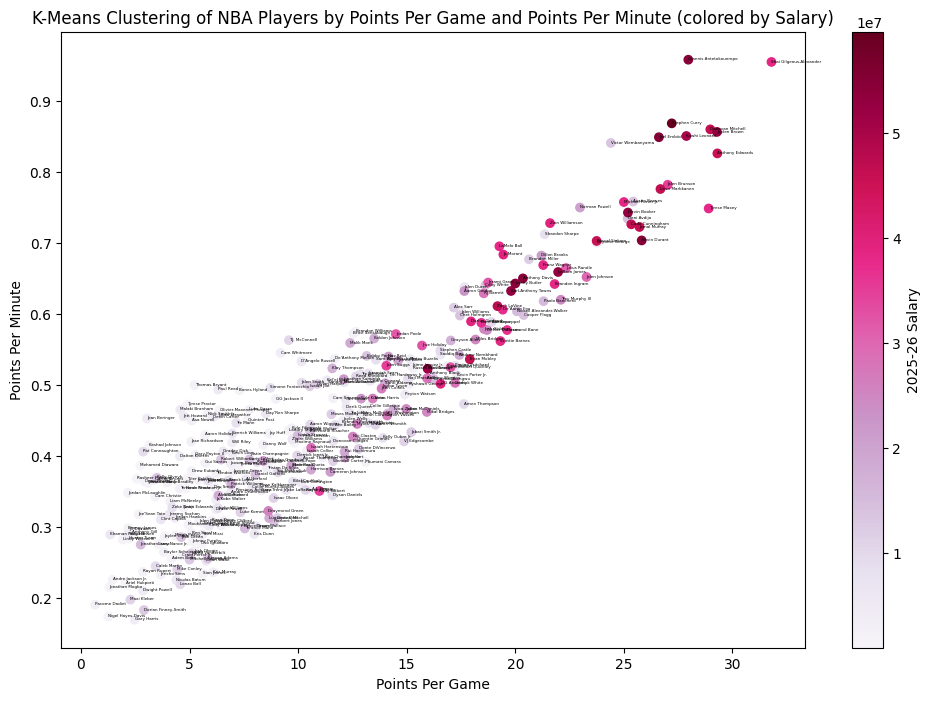

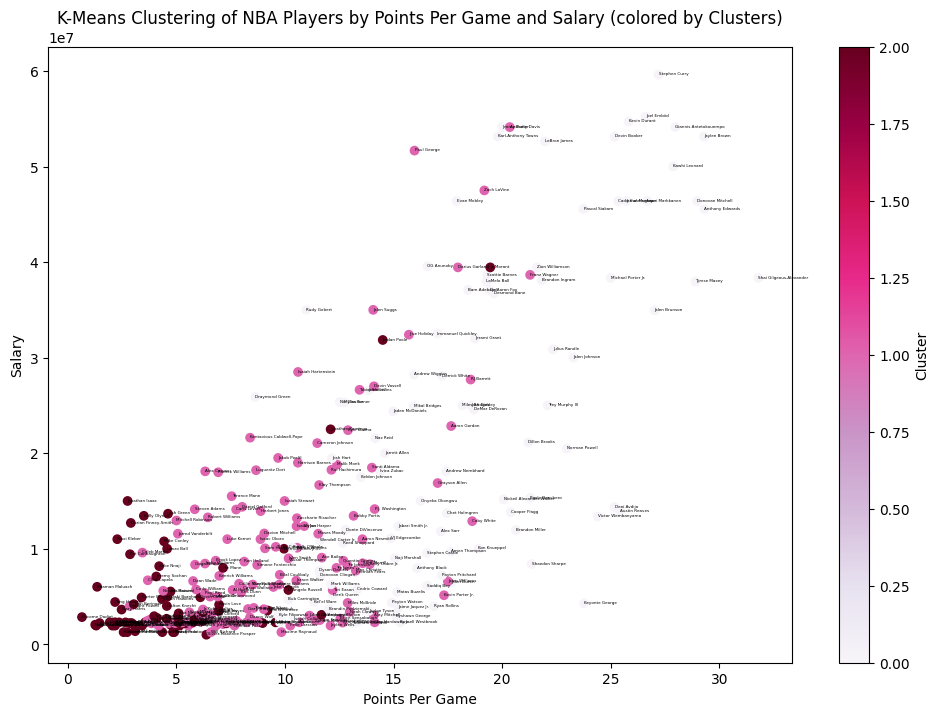

In [36]:
#Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters
# Wanted to see the difference between colored based plots based on clusters and based on salary, so I made 2 different plots to compare them
plt.figure(figsize=(12, 8))
# Am using a scatter plot to visualize the clusters, with points per game on the x-axis and salary on the y-axis, and coloring the points based on their 2025-26 salary using a colormap
plt.scatter(players_filtered['PPG'], players_filtered['PPM'], c=players_filtered['2025-26'], cmap='PuRd')
plt.xlabel('Points Per Game')
plt.ylabel('Points Per Minute')
plt.title('K-Means Clustering of NBA Players by Points Per Game and Points Per Minute (colored by Salary)')

# Annotating the points with the player names for better understanding
# itterows is a function that allows iteration over the rows of the data
# Names overlapping is an issue, so I set the fontsize to 4 and alpha to 1 to make it more readable (it is still not perfect but it is better than before)
for i, player in players_filtered.iterrows():
    plt.annotate(player['Player'], (player['PPG'], player['PPM']), 
                 fontsize=3, alpha=1)

# Adding a colorbar to show the salary range for understanding the color coding of the points
plt.colorbar(label='2025-26 Salary')

plt.show()

plt.figure(figsize=(12, 8))
# Am using a scatter plot to visualize the clusters, with points per game on the x-axis and salary on the y-axis, and coloring the points based on their clusters
plt.scatter(players_filtered['PPG'], players_filtered['2025-26'], c=players_filtered['Cluster'], cmap='PuRd')
plt.xlabel('Points Per Game')
plt.ylabel('Salary')
plt.title('K-Means Clustering of NBA Players by Points Per Game and Salary (colored by Clusters)')

# Annotating the points with the player names for better understanding
# itterows is a function that allows iteration over the rows of the data
# Names overlapping is an issue, so I set the fontsize to 4 and alpha to 1 to make it more readable (it is still not perfect but it is better than before)
for i, player in players_filtered.iterrows():
    plt.annotate(player['Player'], (player['PPG'], player['2025-26']), 
                 fontsize=3, alpha=1)

# Adding a colorbar to show the salary range for understanding the color coding of the points
plt.colorbar(label='Cluster')
plt.show()

In [37]:
#Evaluate the quality of the clustering using total variance explained and silhouette scores
# Total variance explained is 1 - (inertia / total variance), inertia is how spread out the cluster are, total variance is how spread out the data is in general 
# The closer the total variance explained is to 1, the better the clustering is, because it means that the clusters are well defined
total_variance = np.sum(np.var(players_scaled, axis=0)) * len(players_scaled)
variance_explained = 1 - (kmeans.inertia_ / total_variance)
print(variance_explained)

# Silhouette score is a measure of how similar an object is to its own cluster compared to other clusters
silhouette = silhouette_score(players_scaled, kmeans.labels_)
print(silhouette)

0.4100751218103361
0.17709360354268652


In [38]:
#Determine the ideal number of clusters using the elbow method and the silhouette coefficient
inertias = []
silhouette_scores = []
# A silhoutte score needs at least 2 clusters to be calculated, so I will start the range from 2
k_values = range(2,10) 
for k in k_values:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(players_scaled)
    inertias.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(players_scaled, kmeans_test.labels_))

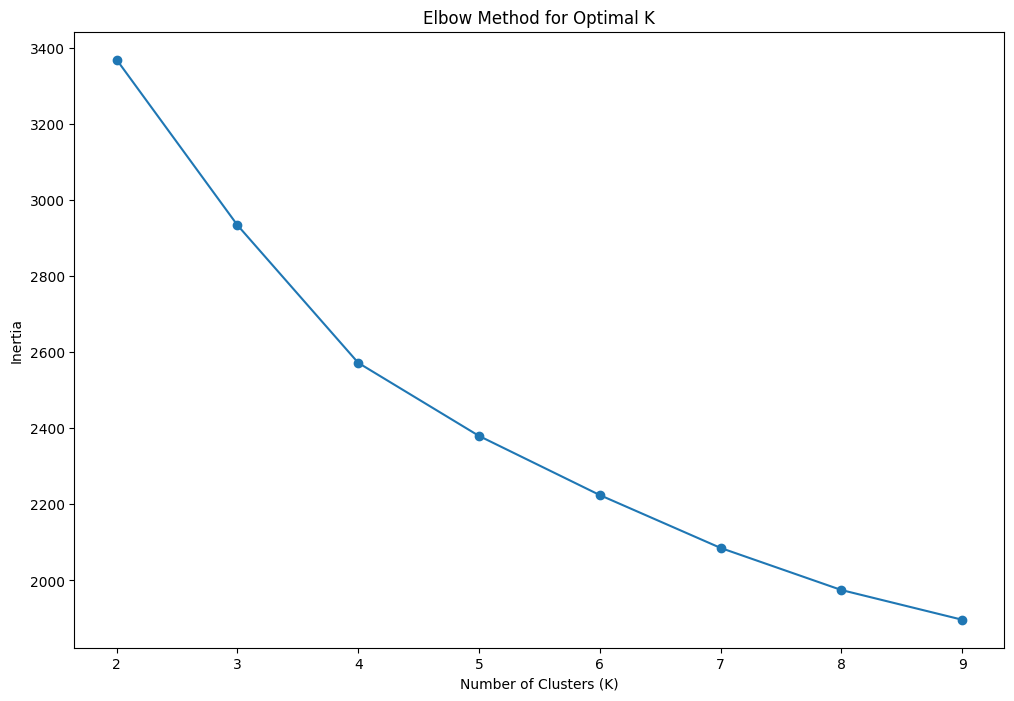

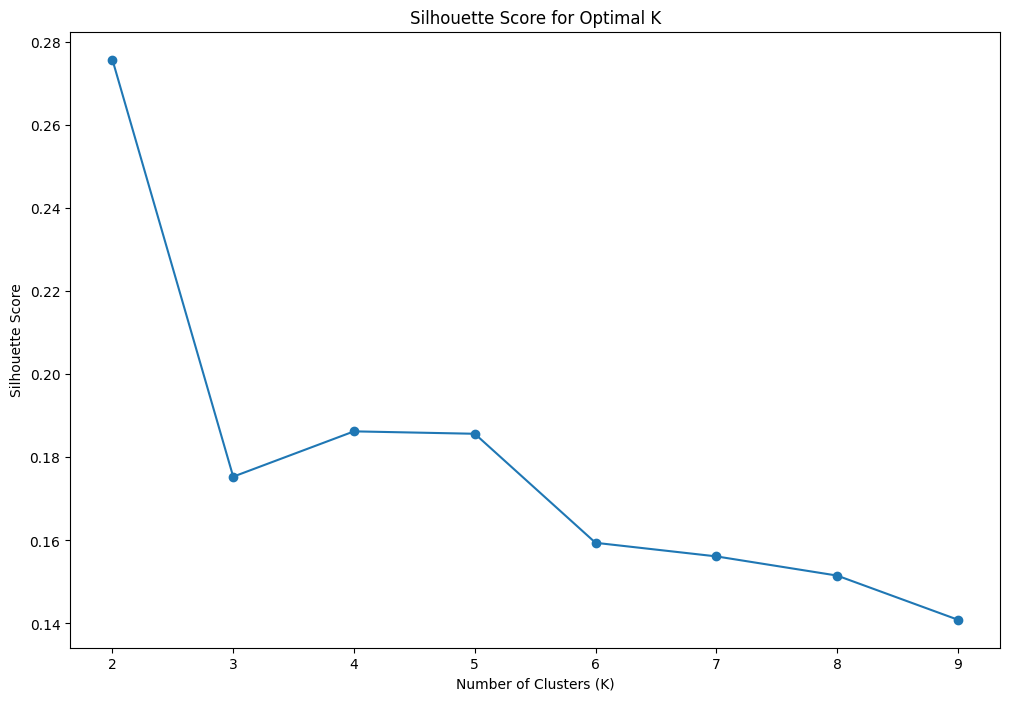

In [39]:
#Visualize the results of the elbow method
# Plot inertia values to find the elbow point where adding more clusters stops improving the model
plt.figure(figsize=(12, 8))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.figure(figsize=(12, 8))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')

plt.show()

Initialization complete
Iteration 0, inertia 4936.95166430924.
Iteration 1, inertia 3462.0814653563393.
Iteration 2, inertia 3416.0679371823776.
Iteration 3, inertia 3388.8594559903295.
Iteration 4, inertia 3378.774449002406.
Iteration 5, inertia 3373.1448614544584.
Iteration 6, inertia 3370.6240154095535.
Iteration 7, inertia 3369.26966696557.
Iteration 8, inertia 3368.1752348280725.
Converged at iteration 8: strict convergence.


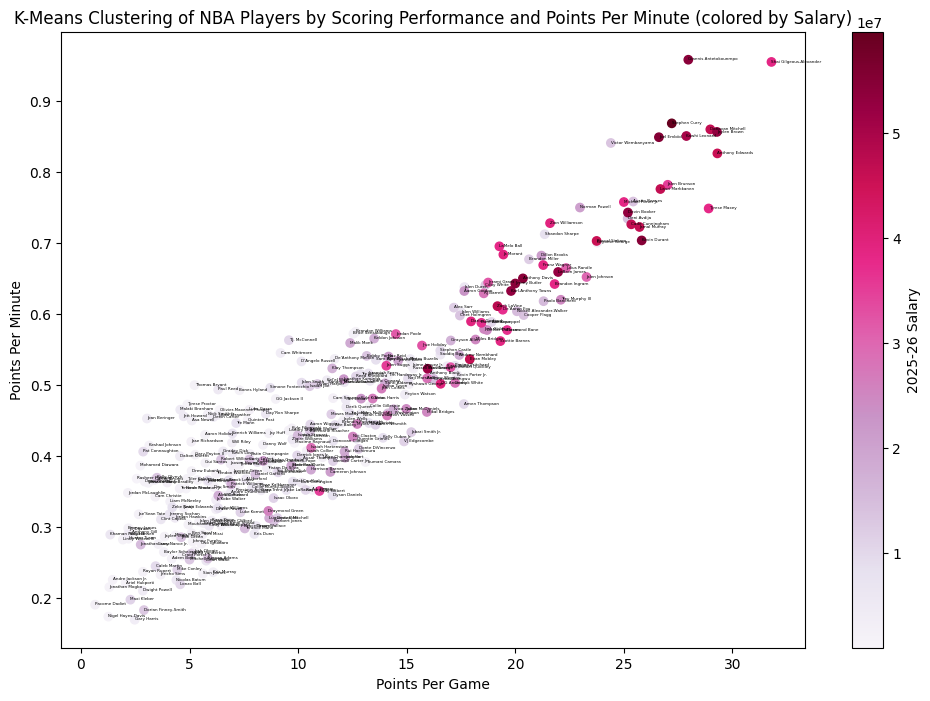

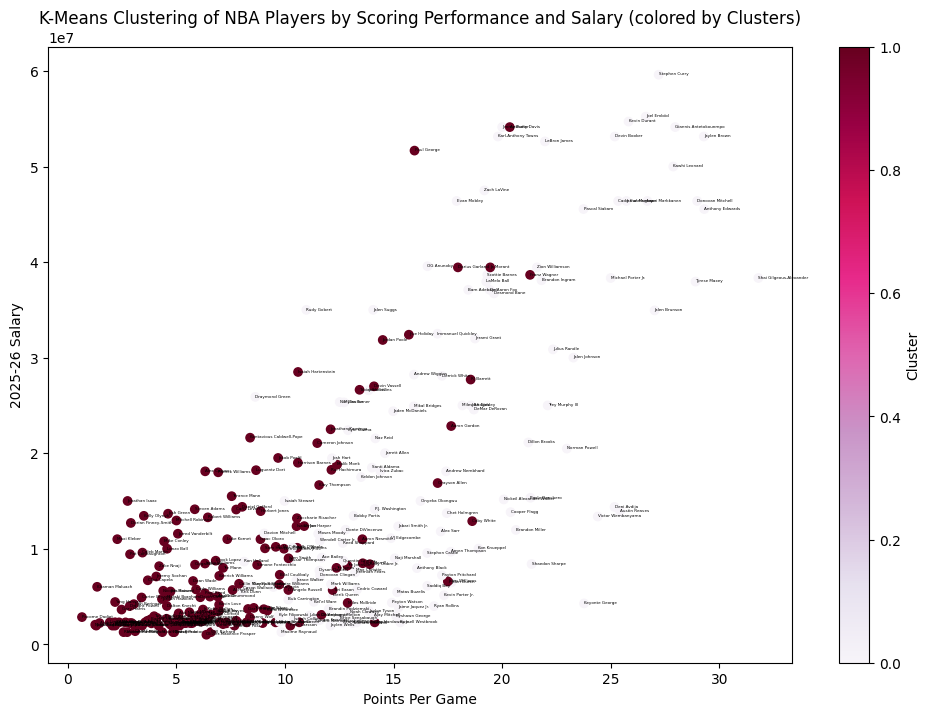

In [42]:
#Use the recommended number of cluster (assuming it's different) to retrain your model and visualize the results
# Number of clusters to form as well as the number of centroids to generate
kmeans = KMeans(n_clusters=2, random_state=42, verbose=1)
kmeans.fit(players_scaled)
players_filtered['Cluster'] = kmeans.labels_

plt.figure(figsize=(12, 8))
# Am using a scatter plot to visualize the clusters, with points per game on the x-axis and points per minute on the y-axis, and coloring the points based on their 2025-26 salary using a colormap
plt.scatter(players_filtered['PPG'], players_filtered['PPM'], c=players_filtered['2025-26'], cmap='PuRd')
plt.xlabel('Points Per Game')
plt.ylabel('Points Per Minute')
plt.title('K-Means Clustering of NBA Players by Scoring Performance and Points Per Minute (colored by Salary)')

# Annotating the points with the player names for better understanding
# itterows is a function that allows iteration over the rows of the data
# Names overlapping is an issue, so I set the fontsize to 4 and alpha to 1 to make it more readable (it is still not perfect but it is better than before)
for i, player in players_filtered.iterrows():
    plt.annotate(player['Player'], (player['PPG'], player['PPM']), 
                 fontsize=3, alpha=1)

# Adding a colorbar to show the salary range for understanding the color coding of the points
plt.colorbar(label='2025-26 Salary')
plt.show()

# Visualize the results of the new clustering with the same variables as before to see if there is a difference in the clusters
plt.figure(figsize=(12, 8))
plt.scatter(players_filtered['PPG'], players_filtered['2025-26'], c=players_filtered['Cluster'], cmap='PuRd')
plt.xlabel('Points Per Game')
plt.ylabel('2025-26 Salary')
plt.title('K-Means Clustering of NBA Players by Scoring Performance and Salary (colored by Clusters)')

# Annotating the points with the player names for better understanding
# itterows is a function that allows iteration over the rows of the data
# Names overlapping is an issue, so I set the fontsize to 4 and alpha to 1 to make it more readable (it is still not perfect but it is better than before)
for i, player in players_filtered.iterrows():
    plt.annotate(player['Player'], (player['PPG'], player['2025-26']), 
                 fontsize=3, alpha=1)

# Adding a colorbar to show the salary range for understanding the color coding of the points
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
#Once again evaluate the quality of the clustering using total variance explained and silhouette scores
# Total variance explained is 1 - (inertia / total variance), inertia is how spread out the cluster are, total variance is how spread out the data is in general
total_variance = np.sum(np.var(players_scaled, axis=0)) * len(players_scaled)
variance_explained = 1 - (kmeans.inertia_ / total_variance)
print(variance_explained)

# Silhouette score is a measure of how similar an object is to its own cluster compared to other clusters
# The sihouette score is bigger when the clusters are well defined, so a higher silhouette score is better
silhouette = silhouette_score(players_scaled, kmeans.labels_)
print(silhouette)

0.3231159093995031
0.2757427910081736


In [ ]:
#Use the model to select players for Mr. Rooney to consider
# Print cluster means to identify which cluster is high vs low performing
print(players_filtered.groupby('Cluster')[['PPG', 'RPG', 'AST', 'STL', 'BLK', '2025-26']].mean())

# Isolate the high performing cluster 
high_performers = players_filtered[players_filtered['Cluster'] == 0]
low_performers = players_filtered[players_filtered['Cluster'] == 1]

# Calculate the median salary to use as a threshold for good vs bad value
median_salary = players_filtered['2025-26'].median()

# the not good players are low performers with a salary above the median 
not_good = low_performers[low_performers['2025-26'] > median_salary]
# the good choices are high performers with a salary below the median
good_choices = high_performers[high_performers['2025-26'] < median_salary]
# the could work players are high performers with a salary above the median, they can be looked at if the good choices are not available
could_work = high_performers[high_performers['2025-26'] >= median_salary]

# View the three categories of players to consider!!
print(not_good[['Player', 'Tm', '2025-26', 'PPG', 'RPG', 'AST', 'STL', 'BLK']].head(4))
print(good_choices[['Player', 'Tm', '2025-26', 'PPG', 'RPG', 'AST', 'STL', 'BLK']].head(4))
print(could_work[['Player', 'Tm', '2025-26', 'PPG', 'RPG', 'AST', 'STL', 'BLK']].head(4))


               PPG       RPG         AST        STL        BLK       2025-26
Cluster                                                                     
0        16.507741  5.611032  177.822222  50.451852  29.600000  1.939765e+07
1         7.239532  3.167204   59.863636  23.943182  13.585227  8.174703e+06
          Player   Tm    2025-26        PPG       RPG    AST   STL   BLK
288    Tre Jones  CHI  8000000.0  12.368421  2.973684  222.0  50.0   7.0
289     Tre Mann  CHO  8000000.0   7.147059  2.294118   73.0  17.0   4.0
290   Zeke Nnaji  DEN  8177778.0   4.205128  2.769231   21.0  13.0  20.0
291  Tre Johnson  WAS  8237640.0  12.875000  2.725000   86.0  26.0  13.0
            Player   Tm    2025-26        PPG       RPG    AST   STL   BLK
17  Maxime Raynaud  SAC  1272870.0   9.833333  6.625000   49.0  24.0  23.0
31    Jaylen Wells  MEM  1955377.0  12.096154  3.423077   86.0  41.0   6.0
34    Oso Ighodaro  PHO  1955377.0   5.545455  4.545455   99.0  51.0  33.0
35     Jamal Shead  TOR  19

In [100]:
#Write up the results in a separate notebook with supporting visualizations and 
# an overview of how and why you made the choices you did. This should be at least 
# 500 words and should be written for a non-technical audience.